In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from cycles import *
from plot_functions import *
import json
import scienceplots


/opt/anaconda3/lib/python3.12/site-packages/numba/__init__.py:48: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy


Stability reached at cycle 24.
Stability reached at cycle 20.
Stability reached at cycle 29.
Stability reached at cycle 30.
Stability reached at cycle 26.
Stability reached at cycle 34.


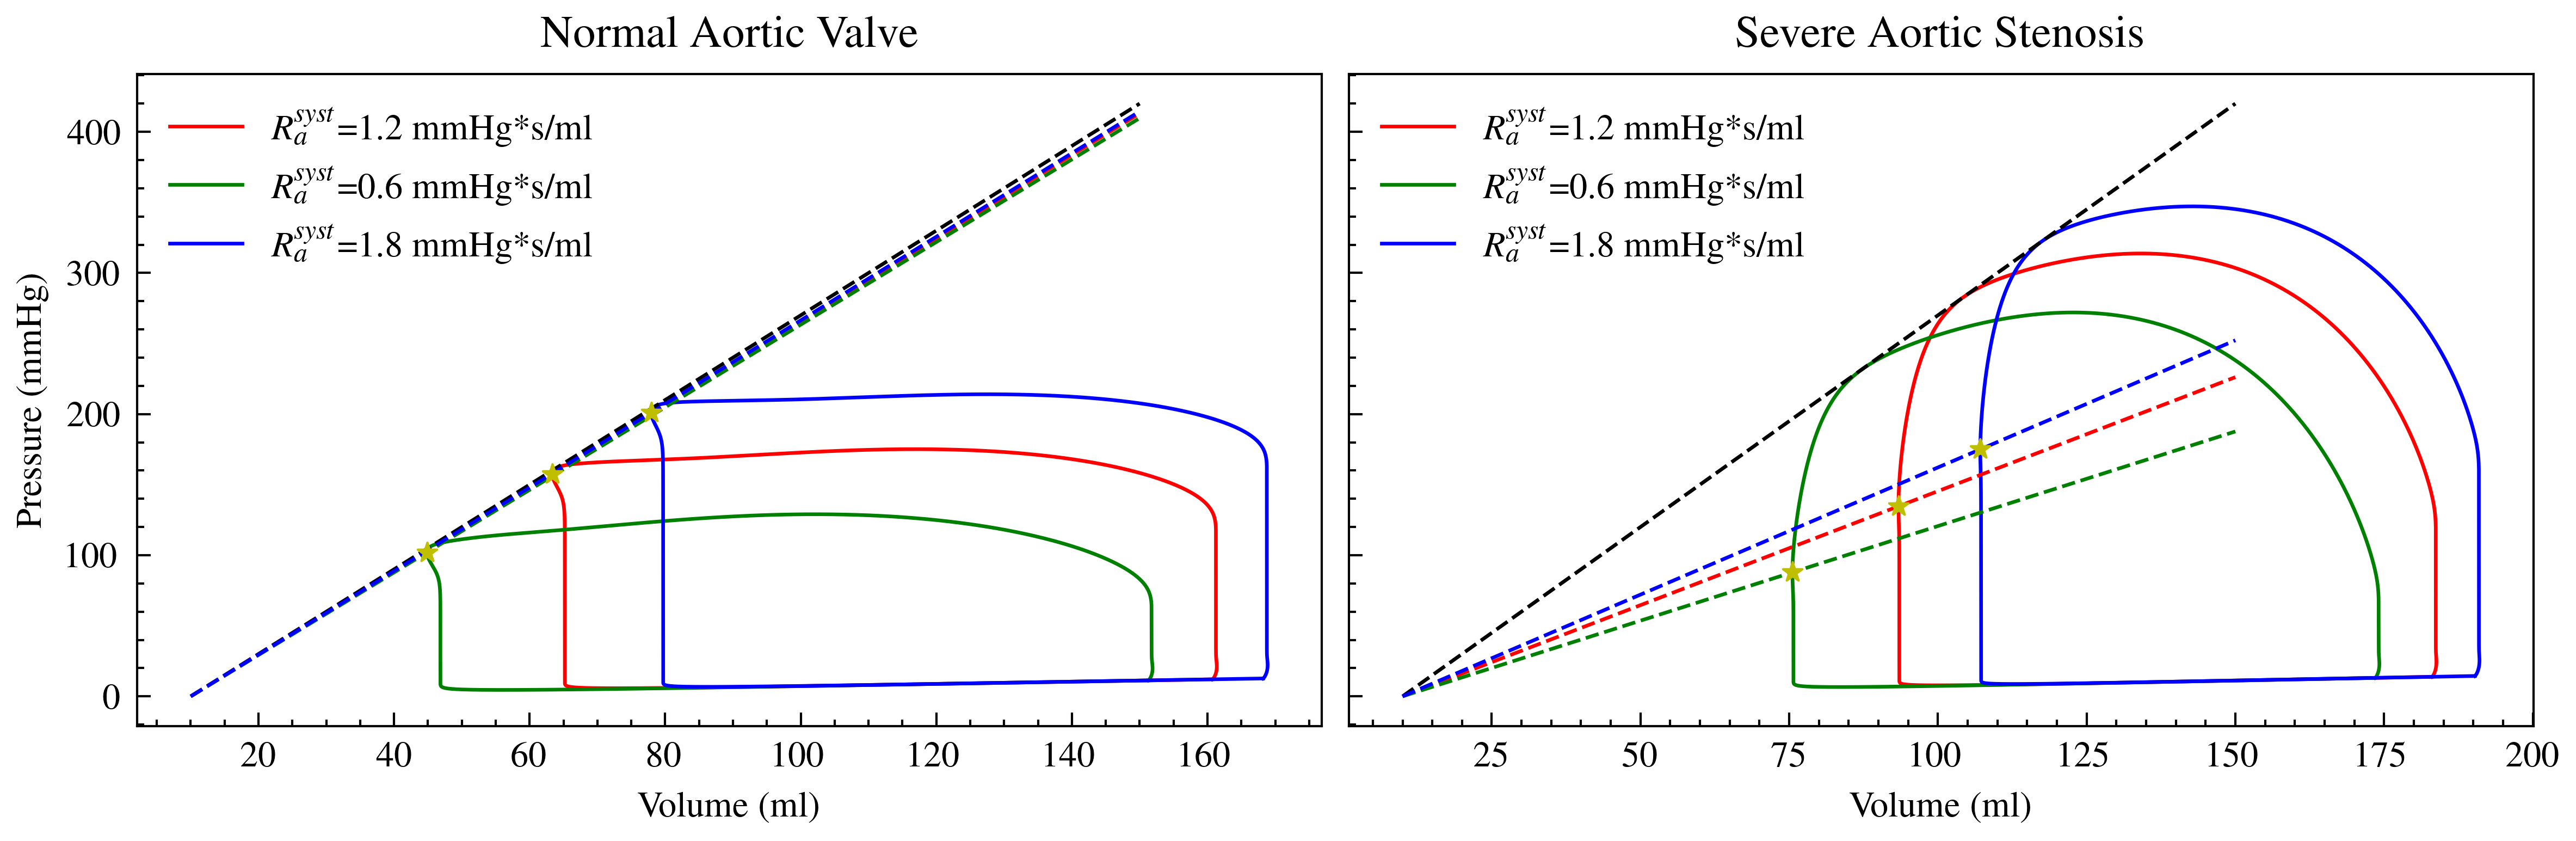

In [3]:
plt.style.use(['science','ieee'])
# plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.top'] = False
plt.rcParams['ytick.right'] = False
plt.rcParams.update({
    "font.family": "serif",   
    "font.serif": ["Times"],  
    "font.size": 8,
    "lines.linewidth": 0.8,       
    "lines.markersize": 3,        
    "axes.linewidth": 0.5,        
    "xtick.major.width": 0.5,     
    "ytick.major.width": 0.5})          
plt.rcParams['patch.linewidth'] = 0.5



CENTIMETERS = 1/2.54
fig, axs = plt.subplots(1, 2, figsize=(20*CENTIMETERS, 6.5*1*CENTIMETERS), sharey=True, layout="constrained")

with open("../input_values/parameters_input.json", "r") as f:
        parameters_input = json.load(f)

parameters_input["valves"]["Amax_av"] = 4.0
results1, _ = multiple_cycles(parameters_input, 500, check_stability=True, store_all=False)
parameters_input["circulation"]["Ra_syst"] = 0.6
results2, _ = multiple_cycles(parameters_input, 500, check_stability=True, store_all=False)
parameters_input["circulation"]["Ra_syst"] = 1.8
results3, _ = multiple_cycles(parameters_input, 500, check_stability=True, store_all=False)

x = np.linspace(parameters_input["chambers"]["V0lv"], 150, 300)
y = parameters_input["chambers"]["Emax_lv"]*(x-parameters_input["chambers"]["V0lv"])
y1 = results1["output_values"]["Ees_lv"] * (x-parameters_input["chambers"]["V0lv"])
y2 = results2["output_values"]["Ees_lv"] * (x-parameters_input["chambers"]["V0lv"])
y3 = results3["output_values"]["Ees_lv"] * (x-parameters_input["chambers"]["V0lv"])
axs[0].plot(results1["chambers"]["Vlv"], results1["chambers"]["Plv"], "r", label=r"$R_{a}^{syst}$=1.2 mmHg*s/ml", linestyle="-")
axs[0].plot(results2["chambers"]["Vlv"], results2["chambers"]["Plv"], "g", label=r"$R_{a}^{syst}$=0.6 mmHg*s/ml", linestyle="-")
axs[0].plot(results3["chambers"]["Vlv"], results3["chambers"]["Plv"], "b", label=r"$R_{a}^{syst}$=1.8 mmHg*s/ml", linestyle="-")
axs[0].plot(x, y, "black", linestyle="--")
axs[0].plot(x, y1, "r", linestyle="--")
axs[0].plot(x, y2, "g", linestyle="--")
axs[0].plot(x, y3, "b", linestyle="--")
x = min(results1["chambers"]["Vlv"])
axs[0].scatter(x, results1["output_values"]["Ees_lv"] * (x-parameters_input["chambers"]["V0lv"]), color="y", s=20, marker="*", zorder=3)
x = min(results2["chambers"]["Vlv"])
axs[0].scatter(x, results2["output_values"]["Ees_lv"] * (x-parameters_input["chambers"]["V0lv"]), color="y", s=20, marker="*", zorder=3)
x = min(results3["chambers"]["Vlv"])
axs[0].scatter(x, results3["output_values"]["Ees_lv"] * (x-parameters_input["chambers"]["V0lv"]), color="y", s=20, marker="*", zorder=3)
axs[0].set_xlabel("Volume (ml)", fontsize=8)
axs[0].set_ylabel("Pressure (mmHg)", fontsize=8)
axs[0].set_title("Normal Aortic Valve", fontsize=10)
axs[0].legend(fontsize=8)

with open("../input_values/parameters_input.json", "r") as f:
        parameters_input = json.load(f)

parameters_input["valves"]["Amax_av"] = 0.5
results1, _ = multiple_cycles(parameters_input, 500, check_stability=True, store_all=False)
parameters_input["circulation"]["Ra_syst"] = 0.6
results2, _ = multiple_cycles(parameters_input, 500, check_stability=True, store_all=False)
parameters_input["circulation"]["Ra_syst"] = 1.8
results3, _ = multiple_cycles(parameters_input, 500, check_stability=True, store_all=False)

x = np.linspace(parameters_input["chambers"]["V0lv"], 150, 300)
y = parameters_input["chambers"]["Emax_lv"]*(x-parameters_input["chambers"]["V0lv"])
y1 = results1["output_values"]["Ees_lv"] * (x-parameters_input["chambers"]["V0lv"])
y2 = results2["output_values"]["Ees_lv"] * (x-parameters_input["chambers"]["V0lv"])
y3 = results3["output_values"]["Ees_lv"] * (x-parameters_input["chambers"]["V0lv"])
axs[1].plot(results1["chambers"]["Vlv"], results1["chambers"]["Plv"], "r", label=r"$R_{a}^{syst}$=1.2 mmHg*s/ml", linestyle="-")
axs[1].plot(results2["chambers"]["Vlv"], results2["chambers"]["Plv"], "g", label=r"$R_{a}^{syst}$=0.6 mmHg*s/ml", linestyle="-")
axs[1].plot(results3["chambers"]["Vlv"], results3["chambers"]["Plv"], "b", label=r"$R_{a}^{syst}$=1.8 mmHg*s/ml", linestyle="-")
axs[1].plot(x, y, "black", linestyle="--")
axs[1].plot(x, y1, "r", linestyle="--")
axs[1].plot(x, y2, "g", linestyle="--")
axs[1].plot(x, y3, "b", linestyle="--")
x = min(results1["chambers"]["Vlv"])
axs[1].scatter(x, results1["output_values"]["Ees_lv"] * (x-parameters_input["chambers"]["V0lv"]), color="y", s=20, marker="*", zorder=3)
x = min(results2["chambers"]["Vlv"])
axs[1].scatter(x, results2["output_values"]["Ees_lv"] * (x-parameters_input["chambers"]["V0lv"]), color="y", s=20, marker="*", zorder=3)
x = min(results3["chambers"]["Vlv"])
axs[1].scatter(x, results3["output_values"]["Ees_lv"] * (x-parameters_input["chambers"]["V0lv"]), color="y", s=20, marker="*", zorder=3)
axs[1].set_xlabel("Volume (ml)", fontsize=8)
axs[1].set_title("Severe Aortic Stenosis", fontsize=10)
axs[1].legend(fontsize=8)

plt.savefig("Figures/pVloops_analysis.png")
plt.show()


Stability reached at cycle 20.
Stability reached at cycle 21.
Stability reached at cycle 21.
Stability reached at cycle 21.
Stability reached at cycle 21.
Stability reached at cycle 21.
Stability reached at cycle 21.
Stability reached at cycle 21.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 22.
Stability reached at cycle 23.
Stability reached at cycle 23.
Stability reached at cycle 23.
Stability reached at cycle 23.
Stability reached at cycle 23.
Stability reached at cycle 23.
Stabilit

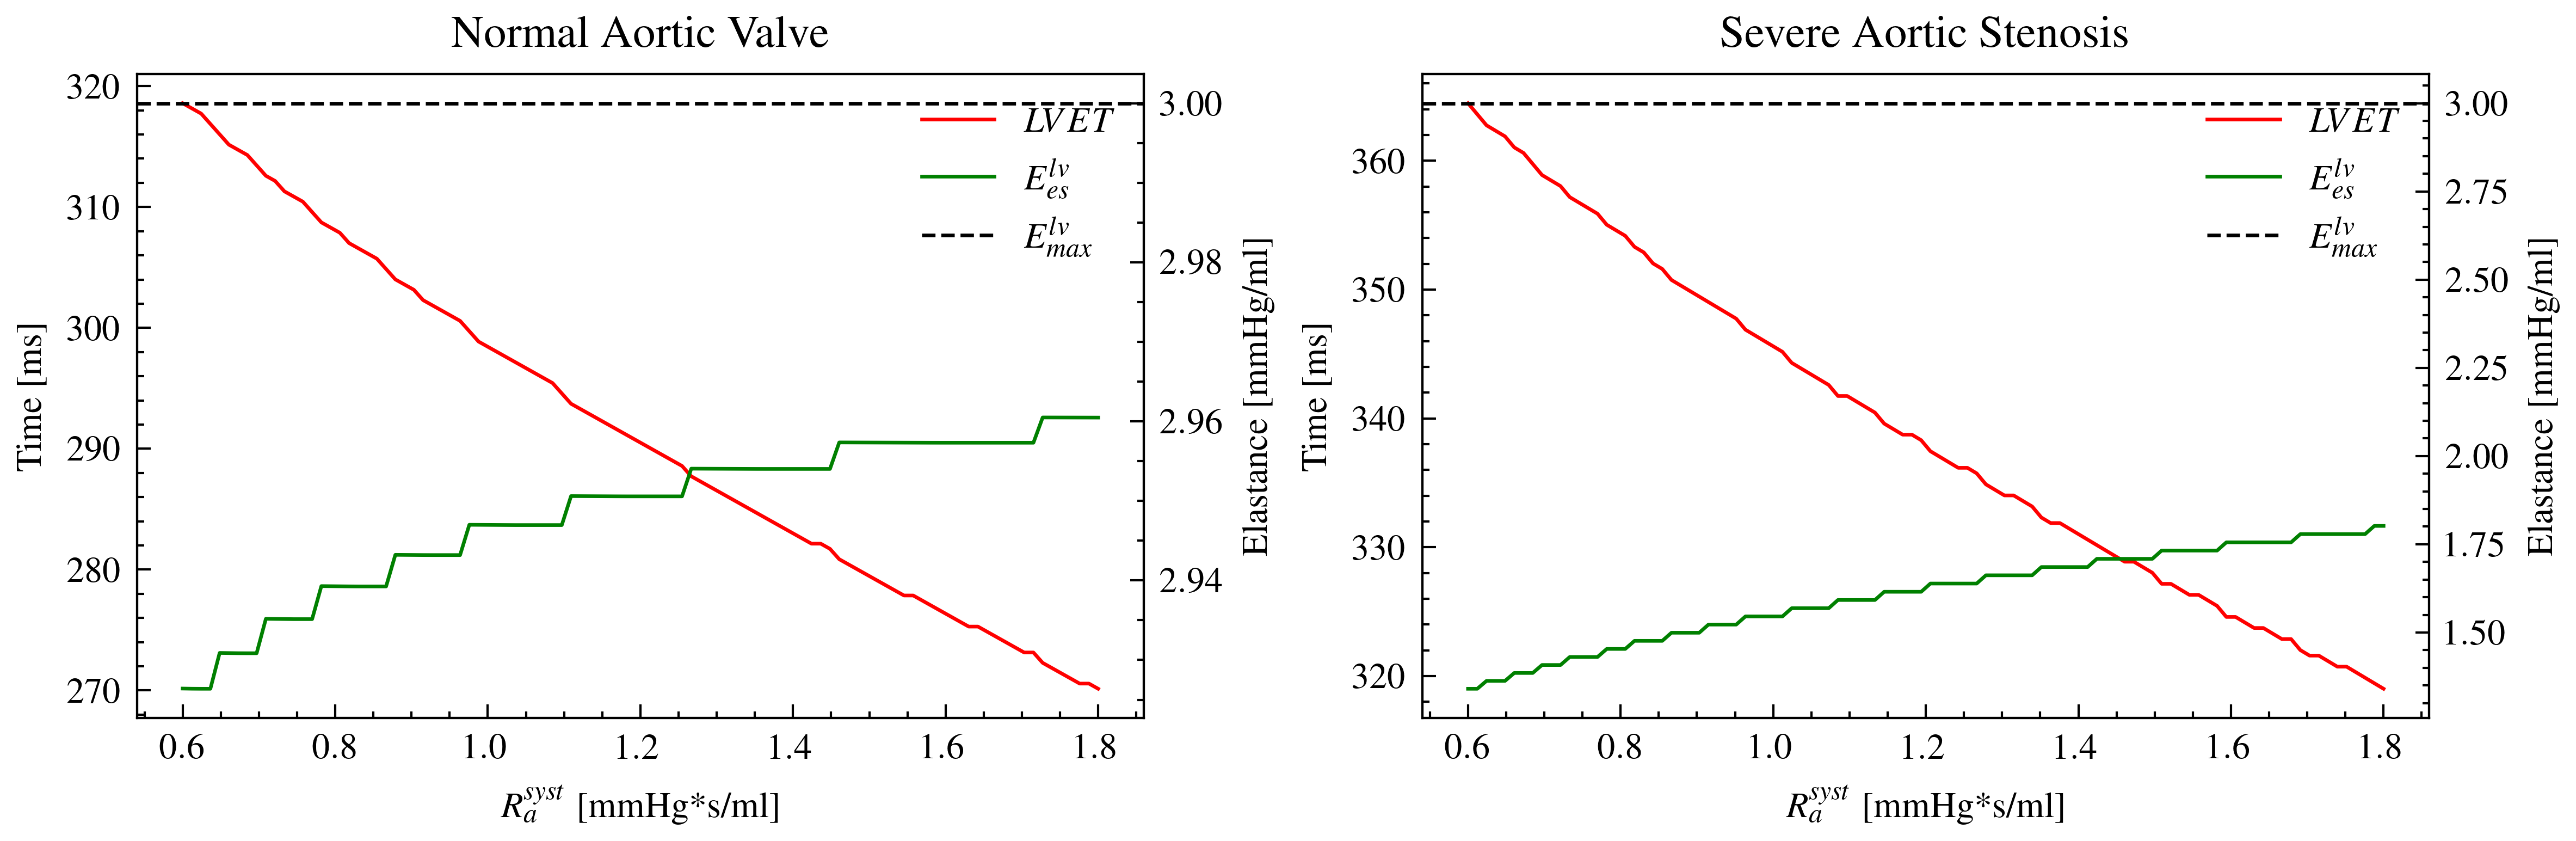

In [4]:
plt.style.use(['science','ieee'])
# plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.top'] = False
plt.rcParams['ytick.right'] = False
plt.rcParams.update({
    "font.family": "serif",   
    "font.serif": ["Times"],  
    "font.size": 8,
    "lines.linewidth": 0.8,       
    "lines.markersize": 3,        
    "axes.linewidth": 0.5,        
    "xtick.major.width": 0.5,     
    "ytick.major.width": 0.5})          
plt.rcParams['patch.linewidth'] = 0.5



CENTIMETERS = 1/2.54
fig, axs = plt.subplots(1, 2, figsize=(20*CENTIMETERS, 6.5*1*CENTIMETERS), layout="constrained")

with open("../input_values/parameters_input.json", "r") as f:
        parameters_input = json.load(f)

LVET_list = []
Ees_lv_list = []
Rasyst_list = np.linspace(0.6, 1.8, 100)
parameters_input["valves"]["Amax_av"] = 4.0
for Rasyst in Rasyst_list:
    parameters_input["circulation"]["Ra_syst"] = Rasyst
    results1, _ = multiple_cycles(parameters_input, 500, check_stability=True, store_all=False)
    LVET_list.append(results1["output_values"]["LVET"]*1000)
    Ees_lv_list.append(results1["output_values"]["Ees_lv"])
    
axs[0].plot(Rasyst_list, LVET_list, "r", label=r"$LVET$", linestyle="-")
ax_twin0 = axs[0].twinx()
ax_twin0.plot(Rasyst_list, Ees_lv_list, "g", label=r"$E_{es}^{lv}$", linestyle="-")
ax_twin0.axhline(y=parameters_input["chambers"]["Emax_lv"], color="black", linestyle="--", label=r"$E_{max}^{lv}$")
axs[0].set_xlabel(r"$R_{a}^{syst}$ [mmHg*s/ml]", fontsize=8)
axs[0].set_ylabel("Time [ms]", fontsize=8)
ax_twin0.set_ylabel("Elastance [mmHg/ml]", fontsize=8)
axs[0].set_title("Normal Aortic Valve", fontsize=10)
lines1, labels1 = axs[0].get_legend_handles_labels()
lines2, labels2 = ax_twin0.get_legend_handles_labels()
axs[0].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

with open("../input_values/parameters_input.json", "r") as f:
        parameters_input = json.load(f)

LVET_list = []
Ees_lv_list = []
Rasyst_list = np.linspace(0.6, 1.8, 100)
parameters_input["valves"]["Amax_av"] = 0.5
for Rasyst in Rasyst_list:
    parameters_input["circulation"]["Ra_syst"] = Rasyst
    results1, _ = multiple_cycles(parameters_input, 500, check_stability=True, store_all=False)
    LVET_list.append(results1["output_values"]["LVET"]*1000)
    Ees_lv_list.append(results1["output_values"]["Ees_lv"])
    
axs[1].plot(Rasyst_list, LVET_list, "r", label=r"$LVET$", linestyle="-")
ax_twin1 = axs[1].twinx()
ax_twin1.plot(Rasyst_list, Ees_lv_list, "g", label=r"$E_{es}^{lv}$", linestyle="-")
ax_twin1.axhline(y=parameters_input["chambers"]["Emax_lv"], color="black", linestyle="--", label=r"$E_{max}^{lv}$")
axs[1].set_xlabel(r"$R_{a}^{syst}$ [mmHg*s/ml]", fontsize=8)
axs[1].set_ylabel("Time [ms]", fontsize=8)
ax_twin1.set_ylabel("Elastance [mmHg/ml]", fontsize=8)
axs[1].set_title("Severe Aortic Stenosis", fontsize=10)
lines1, labels1 = axs[1].get_legend_handles_labels()
lines2, labels2 = ax_twin1.get_legend_handles_labels()
axs[1].legend(lines1 + lines2, labels1 + labels2, fontsize=8)



plt.savefig("Figures/pVloops_LVETandEes_analysis.png")
plt.show()


Stability reached at cycle 39.
Stability reached at cycle 36.
Stability reached at cycle 34.
Stability reached at cycle 32.
Stability reached at cycle 31.
Stability reached at cycle 29.
Stability reached at cycle 28.
Stability reached at cycle 28.
Stability reached at cycle 27.
Stability reached at cycle 26.
Stability reached at cycle 26.
Stability reached at cycle 25.
Stability reached at cycle 25.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 23.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stability reached at cycle 24.
Stabilit

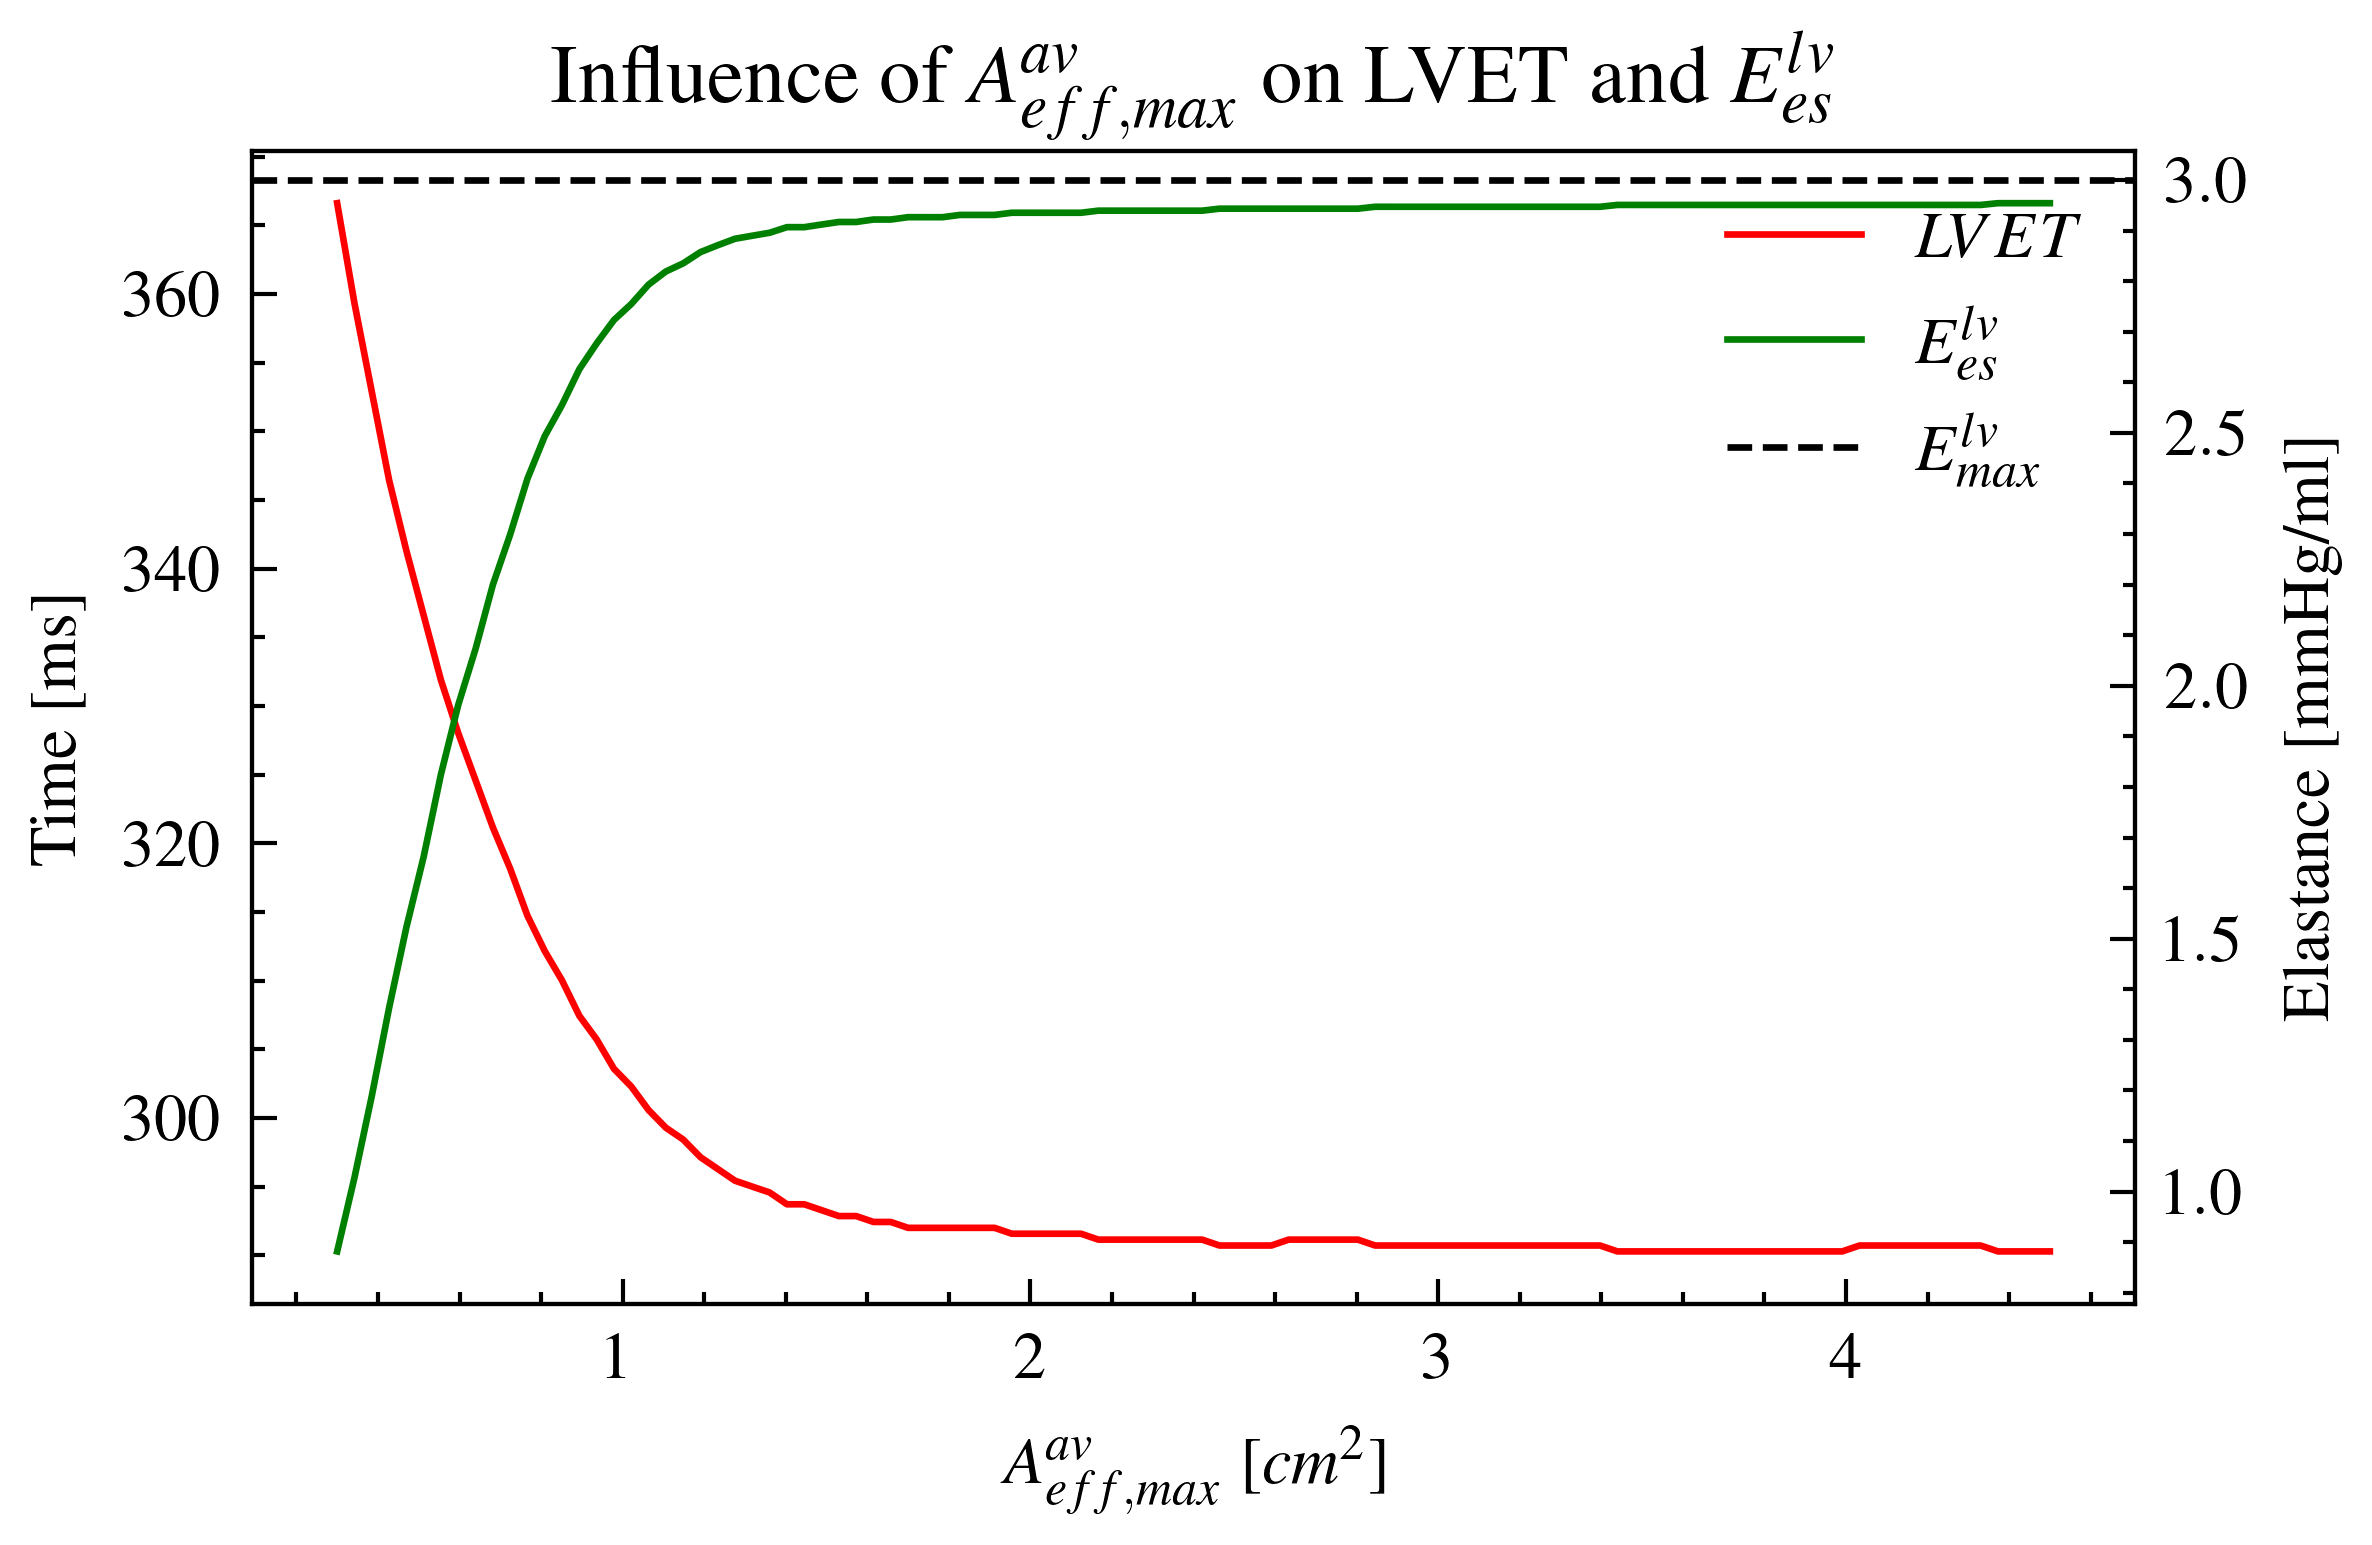

In [5]:
plt.style.use(['science','ieee'])
# plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.top'] = False
plt.rcParams['ytick.right'] = False
plt.rcParams.update({
    "font.family": "serif",   
    "font.serif": ["Times"],  
    "font.size": 8,
    "lines.linewidth": 0.8,       
    "lines.markersize": 3,        
    "axes.linewidth": 0.5,        
    "xtick.major.width": 0.5,     
    "ytick.major.width": 0.5})          
plt.rcParams['patch.linewidth'] = 0.5



CENTIMETERS = 1/2.54
fig, axs = plt.subplots(1, 1, figsize=(10*CENTIMETERS, 6.5*1*CENTIMETERS), layout="constrained")

with open("../input_values/parameters_input.json", "r") as f:
        parameters_input = json.load(f)

LVET_list = []
Ees_lv_list = []
Amaxav_list = np.linspace(0.3, 4.5, 100)
parameters_input["valves"]["Amax_av"] = 4.0
for Amaxav in Amaxav_list:
    parameters_input["valves"]["Amax_av"] = Amaxav
    results1, _ = multiple_cycles(parameters_input, 500, check_stability=True, store_all=False)
    LVET_list.append(results1["output_values"]["LVET"]*1000)
    Ees_lv_list.append(results1["output_values"]["Ees_lv"])
    
axs.plot(Amaxav_list, LVET_list, "r", label=r"$LVET$", linestyle="-")
ax_twin0 = axs.twinx()
ax_twin0.plot(Amaxav_list, Ees_lv_list, "g", label=r"$E_{es}^{lv}$", linestyle="-")
ax_twin0.axhline(y=parameters_input["chambers"]["Emax_lv"], color="black", linestyle="--", label=r"$E_{max}^{lv}$")
axs.set_xlabel(r"$A_{eff,max}^{av}$ [$cm^2$]", fontsize=8)
axs.set_ylabel("Time [ms]", fontsize=8)
ax_twin0.set_ylabel("Elastance [mmHg/ml]", fontsize=8)
axs.set_title(r"Influence of $A_{eff,max}^{av}$ on LVET and $E_{es}^{lv}$", fontsize=10)
lines1, labels1 = axs.get_legend_handles_labels()
lines2, labels2 = ax_twin0.get_legend_handles_labels()
axs.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
plt.savefig("Figures/pVloops_Sao_analysis.png")
plt.show()